## Import Libraries

In [2]:
import os
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import Dataset

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
from transformers.utils.notebook import NotebookProgressCallback

import warnings
warnings.filterwarnings("ignore")

from transformers import logging
logging.set_verbosity_error()

## Read Data

In [3]:
path = "../data/"

train = pd.read_csv(os.path.join(path, "train.csv"))
val = pd.read_csv(os.path.join(path, "val.csv"))
test = pd.read_csv(os.path.join(path, "test.csv"))

print("Train shape:", train.shape)
print("Validation shape:", val.shape)
print("Test shape:", test.shape)

train.head()

Train shape: (11528, 2)
Validation shape: (1442, 2)
Test shape: (1442, 2)


,comment,labels
0,"Я честно хз, но у меня есть подозрение, что тр...",0
1,"Ну зашибись. Мне гланды удалили, остаётся полз...",0
2,Это когда спрос равен предложению. Если повыша...,0
3,"Ужас, только вчера думала о том, а что, если в...",0
4,"Кроме того, в комплектацию входят прибор ночно...",0


## Prepare Hugging Face Datasets

In [4]:
train_ds = Dataset.from_pandas(
    train[["comment", "labels"]],
    preserve_index=False
)

val_ds = Dataset.from_pandas(
    val[["comment", "labels"]],
    preserve_index=False
)

test_ds = Dataset.from_pandas(
    test[["comment", "labels"]],
    preserve_index=False
)

train_ds

Dataset({
    features: ['comment', 'labels'],
    num_rows: 11528
})

## Load ruBERT-tiny Tokenizer

In [5]:
MODEL_NAME = "cointegrated/rubert-tiny2"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

## Tokenization

In [6]:
def tokenize(batch):
    return tokenizer(
        batch["comment"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

In [7]:
train_ds = train_ds.map(tokenize, batched=True)
val_ds = val_ds.map(tokenize, batched=True)
test_ds = test_ds.map(tokenize, batched=True)

Map:   0%|          | 0/11528 [00:00<?, ? examples/s]

Map:   0%|          | 0/1442 [00:00<?, ? examples/s]

Map:   0%|          | 0/1442 [00:00<?, ? examples/s]

## Dataset Formatting

In [8]:
columns = [
    "input_ids",
    "attention_mask",
    "labels"
]

train_ds.set_format("torch", columns=columns)
val_ds.set_format("torch", columns=columns)
test_ds.set_format("torch", columns=columns)

## Define Evaluation Metrics

In [9]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred

    preds = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="binary"
    )

    accuracy = accuracy_score(labels, preds)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

## Load ruBERT-tiny Model

In [10]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

## Training Configuration

In [11]:
training_args = TrainingArguments(
    output_dir="./rubert_tiny_results",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    num_train_epochs=5,

    weight_decay=0.01,

    load_best_model_at_end=True,
    metric_for_best_model="f1",

    logging_strategy="steps",
    logging_steps=50,

    disable_tqdm=False,

    report_to="none"
)

## Trainer Initialization

In [12]:
trainer = Trainer(
    model=model,
    args=training_args,

    train_dataset=train_ds,
    eval_dataset=val_ds,

    compute_metrics=compute_metrics
)

## Model Training

In [13]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.267109,0.236777,0.909847,0.856566,0.877847,0.867076
2,0.277870,0.242242,0.916089,0.850775,0.908903,0.878879
3,0.174795,0.251839,0.916782,0.872690,0.879917,0.876289
4,0.186592,0.269693,0.922330,0.876268,0.894410,0.885246
5,0.148462,0.275073,0.923717,0.876768,0.898551,0.887526


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=3605, training_loss=0.1975667044045029, metrics={'train_runtime': 106.4141, 'train_samples_per_second': 541.657, 'train_steps_per_second': 33.877, 'total_flos': 106262322524160.0, 'train_loss': 0.1975667044045029, 'epoch': 5.0})

In [14]:
trainer.remove_callback(NotebookProgressCallback)

## Validation Evaluation

In [15]:
val_metrics = trainer.evaluate(val_ds)

for metric, value in val_metrics.items():
    print(f"{metric}: {value}")

eval_loss: 0.27507323026657104
eval_accuracy: 0.9237170596393898
eval_precision: 0.8767676767676768
eval_recall: 0.8985507246376812
eval_f1: 0.8875255623721882
eval_runtime: 1.2725
eval_samples_per_second: 1133.223
eval_steps_per_second: 71.514
epoch: 5.0


## Test Evaluation

In [16]:
test_metrics = trainer.evaluate(test_ds)

for metric, value in test_metrics.items():
    print(f"{metric}: {value}")

eval_loss: 0.2604313790798187
eval_accuracy: 0.9216366158113731
eval_precision: 0.8870292887029289
eval_recall: 0.8778467908902692
eval_f1: 0.882414151925078
eval_runtime: 1.251
eval_samples_per_second: 1152.686
eval_steps_per_second: 72.742
epoch: 5.0


## Predictions on Test Data

In [17]:
predictions = trainer.predict(test_ds)

preds = np.argmax(
    predictions.predictions,
    axis=1
)

labels = predictions.label_ids

## Classification Report

In [18]:
print(
    classification_report(
        labels,
        preds,
        target_names=[
            "non-toxic",
            "toxic"
        ]
    )
)

              precision    recall  f1-score   support

   non-toxic       0.94      0.94      0.94       959
       toxic       0.89      0.88      0.88       483

    accuracy                           0.92      1442
   macro avg       0.91      0.91      0.91      1442
weighted avg       0.92      0.92      0.92      1442



## Confusion Matrix

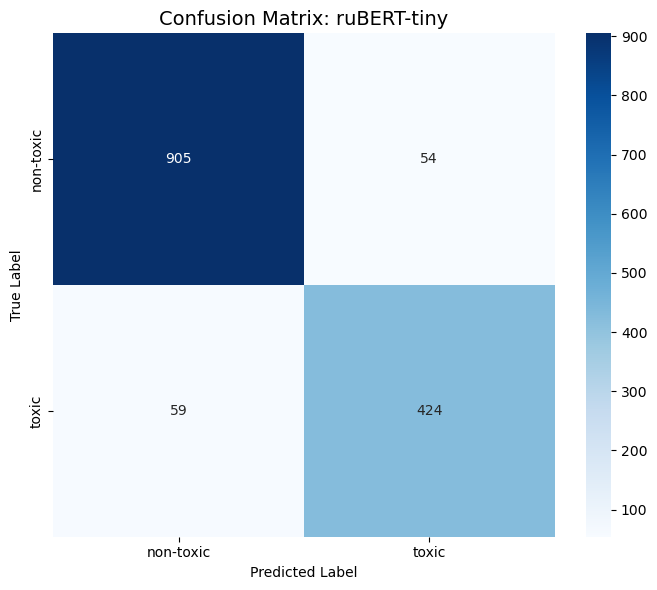

In [19]:
cm = confusion_matrix(labels, preds)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["non-toxic", "toxic"],
    yticklabels=["non-toxic", "toxic"],
    cbar=True
)

plt.title("Confusion Matrix: ruBERT-tiny", fontsize=14)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()

## Save model

In [21]:
SAVE_PATH = "../experiments/rubert_tiny"

trainer.save_model(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)

print(f"Model saved to: {SAVE_PATH}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: ../experiments/rubert_tiny


## Conclusions

In this experiment, the ruBERT-tiny model was fine-tuned for the binary toxic comment classification task.

The model achieved a Macro F1-score of 0.91 on the test set. For the toxic class specifically, the F1-score reached 0.88. Compared with the results reported in the original paper (F1 = 0.922 for the toxic class), the obtained performance is slightly lower, which may be explained by differences in training configuration, number of epochs, hyperparameters, and dataset preprocessing.

- Macro F1 = 0.91
- Toxic F1 = 0.88
- Paper Toxic F1 = 0.922